# 📖 Quranic Arabic Corpus — Morphological Analysis

Interactive analysis of the complete morphological annotation of the Quran (128K+ segments).  
Data source: [Quranic Arabic Corpus v0.4](http://corpus.quran.com) converted to Arabic script with expanded feature columns.

## 1. Bibliotheken laden

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path

# Arabic text support in matplotlib
plt.rcParams['font.family'] = ['Arial Unicode MS', 'DejaVu Sans', 'sans-serif']
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

pd.set_option('display.max_columns', 30)
pd.set_option('display.max_colwidth', 40)
pd.set_option('display.width', 200)

Matplotlib is building the font cache; this may take a moment.


## 2. Data laden en inspecteren

In [2]:
df = pd.read_csv('quranic-corpus-arabic.tsv', sep='\t')
print(f"Totaal segmenten: {len(df):,}")
print(f"Kolommen: {list(df.columns)}\n")
df.head(15)

Totaal segmenten: 128,219
Kolommen: ['surah', 'ayah', 'word', 'segment', 'form_bw', 'form_ar', 'tag', 'segment_type', 'pos', 'lemma', 'lemma_ar', 'root', 'root_ar', 'aspect', 'verb_form', 'voice', 'derivation', 'person', 'gender', 'number', 'case', 'mood', 'state', 'prefix', 'suffix_pron', 'special']



,surah,ayah,word,segment,form_bw,form_ar,tag,segment_type,pos,lemma,lemma_ar,root,root_ar,aspect,verb_form,voice,derivation,person,gender,number,case,mood,state,prefix,suffix_pron,special
0,1,1,1,1,bi,بِ,P,PREFIX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,bi+,NaN,NaN
1,1,1,1,2,somi,سْمِ,N,STEM,N,{som,ٱسْم,smw,سمو,NaN,NaN,NaN,NaN,NaN,M,NaN,GEN,NaN,NaN,NaN,NaN,NaN
2,1,1,2,1,{ll~ahi,ٱللَّهِ,PN,STEM,PN,{ll~ah,ٱللَّه,Alh,اله,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GEN,NaN,NaN,NaN,NaN,NaN
3,1,1,3,1,{l,ٱل,DET,PREFIX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Al+,NaN,NaN
4,1,1,3,2,r~aHoma`ni,رَّحْمَٰنِ,ADJ,STEM,ADJ,r~aHoma`n,رَّحْمَٰن,rHm,رحم,NaN,NaN,NaN,NaN,NaN,M,S,GEN,NaN,NaN,NaN,NaN,NaN
5,1,1,4,1,{l,ٱل,DET,PREFIX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Al+,NaN,NaN
6,1,1,4,2,r~aHiymi,رَّحِيمِ,ADJ,STEM,ADJ,r~aHiym,رَّحِيم,rHm,رحم,NaN,NaN,NaN,NaN,NaN,M,S,GEN,NaN,NaN,NaN,NaN,NaN
7,1,2,1,1,{lo,ٱلْ,DET,PREFIX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Al+,NaN,NaN
8,1,2,1,2,Hamodu,حَمْدُ,N,STEM,N,Hamod,حَمْد,Hmd,حمد,NaN,NaN,NaN,NaN,NaN,M,NaN,NOM,NaN,NaN,NaN,NaN,NaN
9,1,2,2,1,li,لِ,P,PREFIX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,l:P+,NaN,NaN


In [3]:
# Overzicht van kolom-types en vulling
print("── Kolomtypes en niet-lege waarden ──\n")
info = pd.DataFrame({
    'type': df.dtypes,
    'niet_leeg': df.notna().sum(),
    'percentage': (df.notna().sum() / len(df) * 100).round(1)
})
info

── Kolomtypes en niet-lege waarden ──



,type,niet_leeg,percentage
surah,int64,128219,100.0
ayah,int64,128219,100.0
word,int64,128219,100.0
segment,int64,128219,100.0
form_bw,object,128011,99.8
form_ar,object,128011,99.8
tag,object,128219,100.0
segment_type,object,128219,100.0
pos,object,77915,60.8
lemma,object,74608,58.2


In [4]:
# Handige subsets aanmaken
stems = df[df['segment_type'] == 'STEM'].copy()
verbs = stems[stems['pos'] == 'V'].copy()
nouns = stems[stems['pos'] == 'N'].copy()
adjectives = stems[stems['pos'] == 'ADJ'].copy()

print(f"Stems:       {len(stems):>7,}")
print(f"  Werkwoorden: {len(verbs):>7,}")
print(f"  Zelfst.nw.:  {len(nouns):>7,}")
print(f"  Bijv.nw.:    {len(adjectives):>7,}")
print(f"\nWoordsoorten (POS) in stems:")
stems['pos'].value_counts()

Stems:        77,915
  Werkwoorden:  19,356
  Zelfst.nw.:   25,136
  Bijv.nw.:      1,961

Woordsoorten (POS) in stems:


pos
N       25136
V       19356
P        7679
PN       3911
REL      3575
PRON     3301
NEG      2688
ACC      2283
ADJ      1961
T        1166
DEM      1059
COND     1049
CONJ      756
SUB       684
LOC       669
RES       558
INTG      439
CERT      414
PRO       332
PREV      162
RET       122
EXP       104
INC        90
EXL        66
AMD        65
INT        47
FUT        42
ANS        40
EXH        40
SUR        35
AVR        33
INL        30
SUP        21
IMPN        2
Name: count, dtype: int64

## 3. Wortelanalyse (جذور)

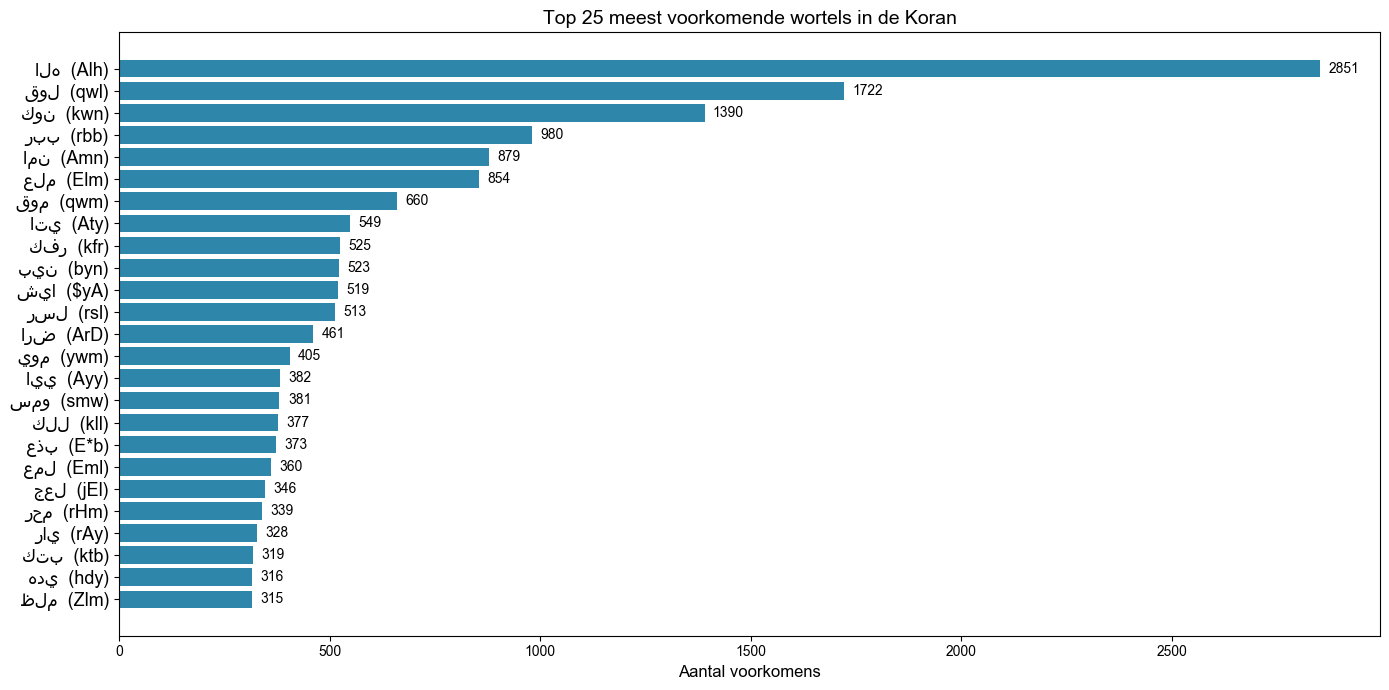


Totaal unieke wortels: 1,642
  Drieletterwortels: 1,602
  Vierletterwortels: 40


In [5]:
# Top 25 meest voorkomende wortels
root_counts = stems[stems['root_ar'].notna()].groupby(['root', 'root_ar']).size().reset_index(name='freq')
root_counts = root_counts.sort_values('freq', ascending=False)

top25 = root_counts.head(25)
fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(range(len(top25)), top25['freq'], color='#2E86AB')
ax.set_yticks(range(len(top25)))
ax.set_yticklabels([f"{row.root_ar}  ({row.root})" for row in top25.itertuples()], fontsize=13)
ax.invert_yaxis()
ax.set_xlabel('Aantal voorkomens', fontsize=12)
ax.set_title('Top 25 meest voorkomende wortels in de Koran', fontsize=14)
for i, v in enumerate(top25['freq']):
    ax.text(v + 20, i, str(v), va='center', fontsize=10)
plt.tight_layout()
plt.show()

print(f"\nTotaal unieke wortels: {len(root_counts):,}")
print(f"  Drieletterwortels: {(root_counts['root'].str.len() == 3).sum():,}")
print(f"  Vierletterwortels: {(root_counts['root'].str.len() == 4).sum():,}")

In [6]:
# Hapax legomena: wortels die slechts 1x voorkomen
hapax = root_counts[root_counts['freq'] == 1]
print(f"Hapax legomena (wortels die 1x voorkomen): {len(hapax)}")
print(f"Dat is {len(hapax)/len(root_counts)*100:.1f}% van alle wortels\n")
print("Voorbeelden:")
hapax.head(20)[['root_ar', 'root']].to_string(index=False)

Hapax legomena (wortels die 1x voorkomen): 395
Dat is 24.1% van alle wortels

Voorbeelden:


'root_ar root\n    غبن  gbn\n    تفث  tfv\n    وحش  wH$\n    وضن  wDn\n    اود  Awd\n    شفه  $fh\n    ايم  Aym\n    شعل  $El\n    زهر  zhr\n    تيه  tyh\n    ضيز  Dyz\n    دسو  dsw\n    غدق  gdq\n    جبت  jbt\n    ضير  Dyr\n    اثل  Avl\n    زهد  zhd\n    جبن  jbn\n    زفف  zff\n    هزل  hzl'

## 4. Werkwoordanalyse (أفعال)

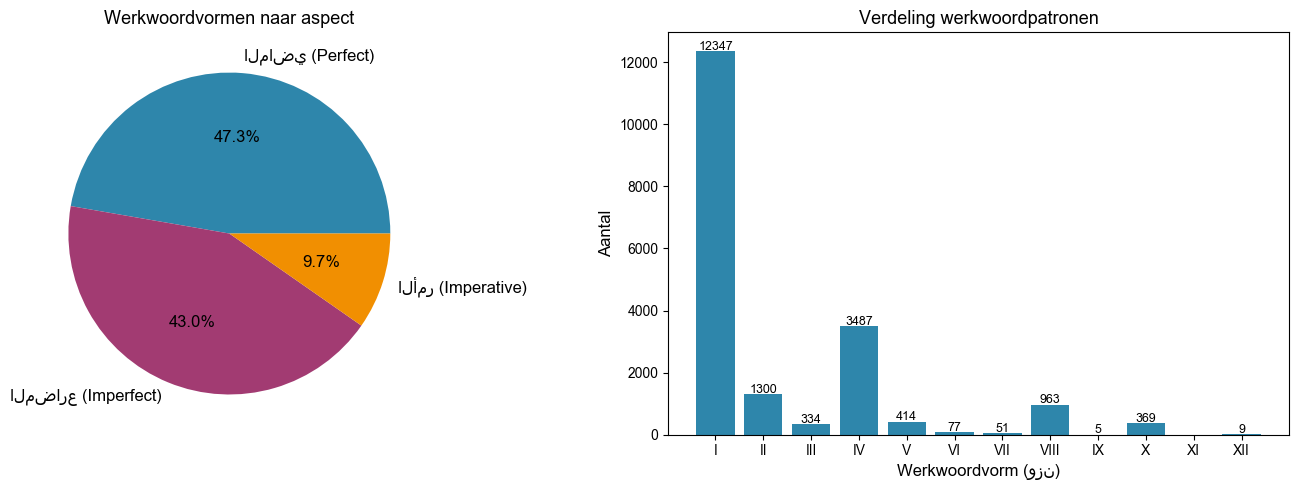

In [7]:
# Aspect verdeling (الماضي / المضارع / الأمر)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Taartdiagram
aspect_counts = verbs['aspect'].value_counts()
aspect_labels = {'PERF': 'الماضي (Perfect)', 'IMPF': 'المضارع (Imperfect)', 'IMPV': 'الأمر (Imperative)'}
labels = [aspect_labels.get(a, a) for a in aspect_counts.index]
colors = ['#2E86AB', '#A23B72', '#F18F01']
axes[0].pie(aspect_counts.values, labels=labels, autopct='%1.1f%%', colors=colors, textprops={'fontsize': 12})
axes[0].set_title('Werkwoordvormen naar aspect', fontsize=13)

# Werkwoordpatronen (أوزان)
form_map = {'': 'I', 'II': 'II', 'III': 'III', 'IV': 'IV', 'V': 'V', 
            'VI': 'VI', 'VII': 'VII', 'VIII': 'VIII', 'IX': 'IX', 'X': 'X', 'XI': 'XI', 'XII': 'XII'}
verb_forms = verbs['verb_form'].fillna('I').map(lambda x: x if x else 'I')
form_order = ['I', 'II', 'III', 'IV', 'V', 'VI', 'VII', 'VIII', 'IX', 'X', 'XI', 'XII']
form_counts = verb_forms.value_counts().reindex(form_order).fillna(0)
axes[1].bar(form_counts.index, form_counts.values, color='#2E86AB')
axes[1].set_xlabel('Werkwoordvorm (وزن)', fontsize=12)
axes[1].set_ylabel('Aantal', fontsize=12)
axes[1].set_title('Verdeling werkwoordpatronen', fontsize=13)
for i, v in enumerate(form_counts.values):
    if v > 0:
        axes[1].text(i, v + 50, str(int(v)), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

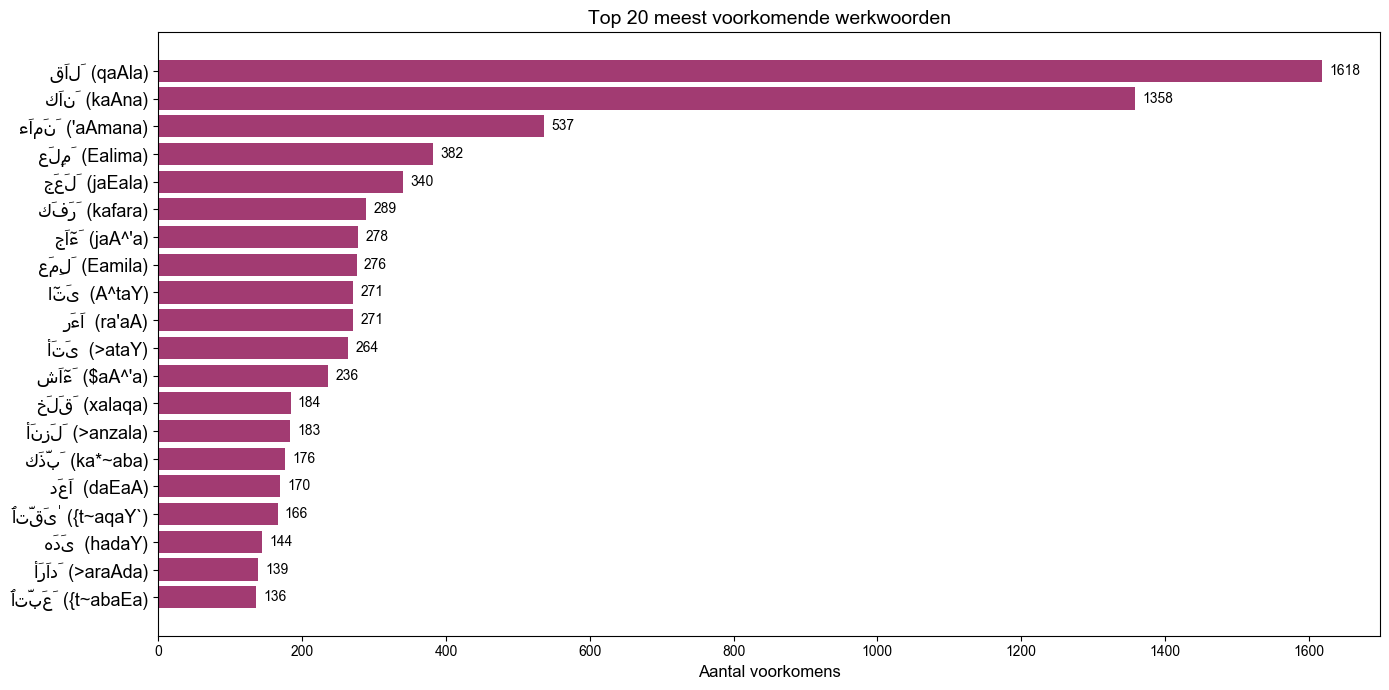

Unieke werkwoorden (lemma's): 1,475


In [8]:
# Top 20 werkwoorden
top_verbs = verbs.groupby(['lemma', 'lemma_ar']).size().reset_index(name='freq')
top_verbs = top_verbs.sort_values('freq', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(14, 7))
ax.barh(range(len(top_verbs)), top_verbs['freq'], color='#A23B72')
ax.set_yticks(range(len(top_verbs)))
ax.set_yticklabels([f"{row.lemma_ar}  ({row.lemma})" for row in top_verbs.itertuples()], fontsize=13)
ax.invert_yaxis()
ax.set_xlabel('Aantal voorkomens', fontsize=12)
ax.set_title('Top 20 meest voorkomende werkwoorden', fontsize=14)
for i, v in enumerate(top_verbs['freq']):
    ax.text(v + 10, i, str(v), va='center', fontsize=10)
plt.tight_layout()
plt.show()

print(f"Unieke werkwoorden (lemma's): {verbs['lemma'].nunique():,}")

## 5. Zelfstandig naamwoord & bijvoeglijk naamwoord analyse (أسماء)

In [ ]:
# Grammaticale naamval, geslacht en bepaaldheid
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Naamval (إعراب)
case_counts = nouns['case'].value_counts()
case_labels = {'NOM': 'مرفوع (Nominatief)', 'ACC': 'منصوب (Accusatief)', 'GEN': 'مجرور (Genitief)'}
labels = [case_labels.get(c, c) for c in case_counts.index]
axes[0].pie(case_counts.values, labels=labels, autopct='%1.1f%%', 
            colors=['#2E86AB', '#A23B72', '#F18F01'], textprops={'fontsize': 11})
axes[0].set_title('Naamvallen (إعراب)', fontsize=13)

# Geslacht
gender_data = stems[stems['gender'].notna()]['gender'].value_counts()
gender_labels = {'M': 'مذكر (Mannelijk)', 'F': 'مؤنث (Vrouwelijk)'}
labels = [gender_labels.get(g, g) for g in gender_data.index]
axes[1].pie(gender_data.values, labels=labels, autopct='%1.1f%%',
            colors=['#2E86AB', '#E8375A'], textprops={'fontsize': 11})
axes[1].set_title('Geslacht (جنس)', fontsize=13)

# Getal (enkelvoud/meervoud/tweevoud)
number_data = stems[stems['number'].notna()]['number'].value_counts()
number_labels = {'S': 'مفرد (Enkelvoud)', 'P': 'جمع (Meervoud)', 'D': 'مثنى (Tweevoud)'}
labels = [number_labels.get(n, n) for n in number_data.index]
axes[2].pie(number_data.values, labels=labels, autopct='%1.1f%%',
            colors=['#2E86AB', '#A23B72', '#F18F01'], textprops={'fontsize': 11})
axes[2].set_title('Getal (عدد)', fontsize=13)

plt.tight_layout()
plt.show()

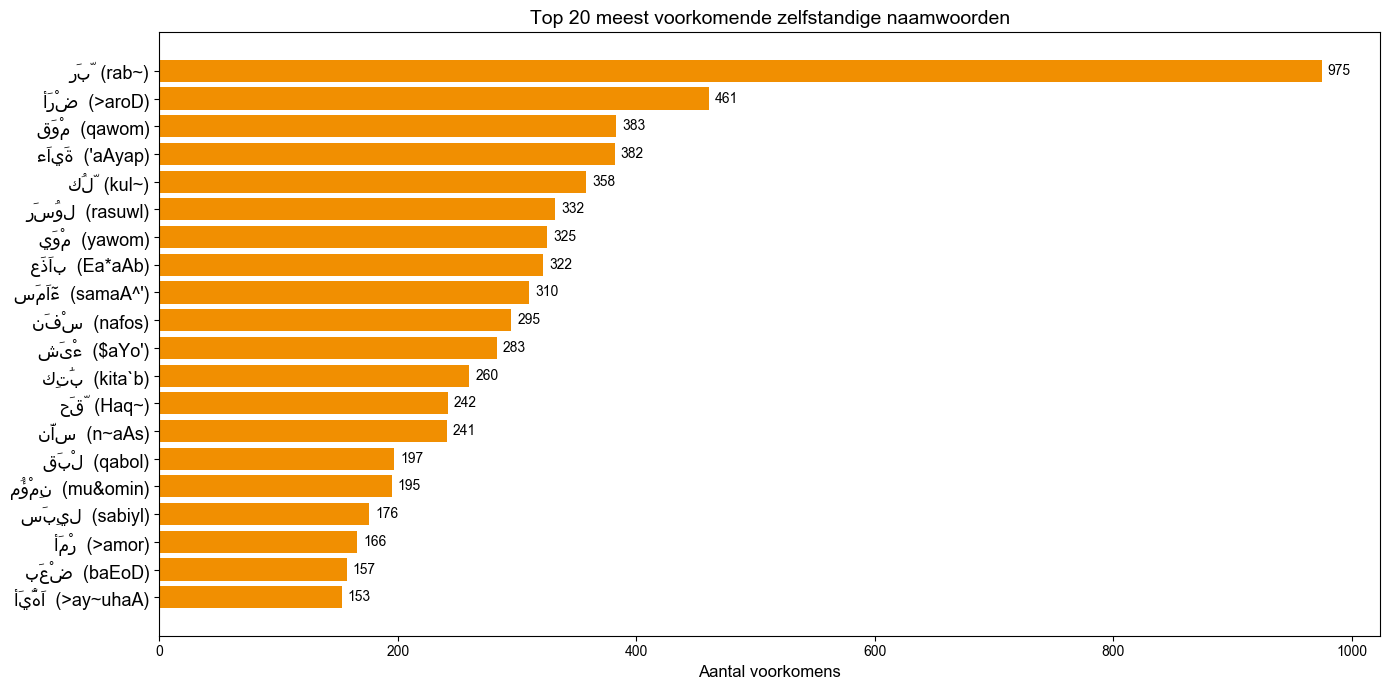

In [9]:
# Top 20 zelfstandige naamwoorden
top_nouns = nouns.groupby(['lemma', 'lemma_ar']).size().reset_index(name='freq')
top_nouns = top_nouns.sort_values('freq', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(14, 7))
ax.barh(range(len(top_nouns)), top_nouns['freq'], color='#F18F01')
ax.set_yticks(range(len(top_nouns)))
ax.set_yticklabels([f"{row.lemma_ar}  ({row.lemma})" for row in top_nouns.itertuples()], fontsize=13)
ax.invert_yaxis()
ax.set_xlabel('Aantal voorkomens', fontsize=12)
ax.set_title('Top 20 meest voorkomende zelfstandige naamwoorden', fontsize=14)
for i, v in enumerate(top_nouns['freq']):
    ax.text(v + 5, i, str(v), va='center', fontsize=10)
plt.tight_layout()
plt.show()

## 6. Soera-niveau statistieken

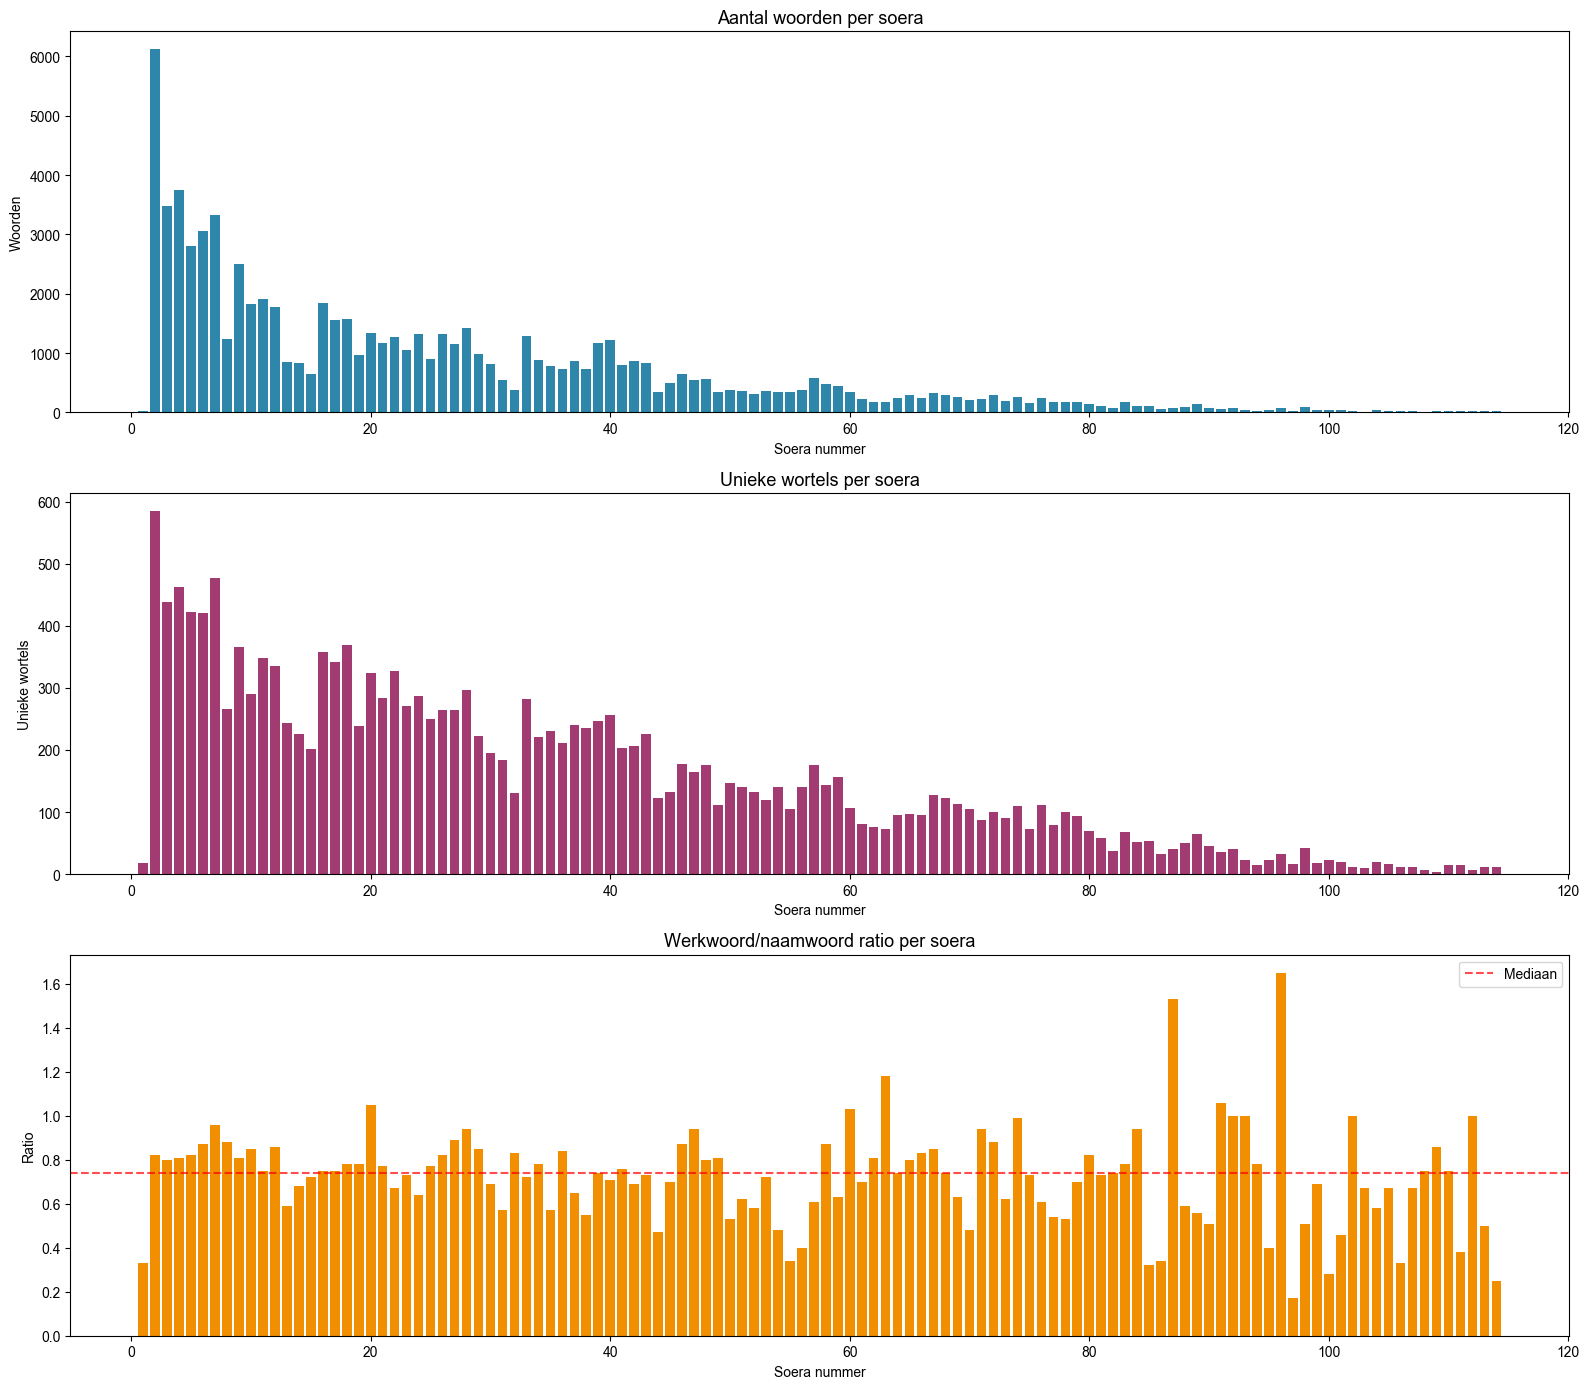

── Langste soera's ──
       woorden  unieke_wortels
surah                         
2         6116             585
4         3747             462
3         3481             439
7         3320             477
6         3050             421
5         2804             422
9         2498             366
11        1917             348
16        1844             358
10        1833             290

── Kortste soera's ──
       woorden  unieke_wortels
surah                         
108         10               7
103         14               9
112         15               7
106         17              11
110         19              15
114         20              11
105         23              17
111         23              15
113         23              11
107         25              12


In [10]:
# Woorden per soera + unieke wortels per soera
words_per_surah = df.drop_duplicates(subset=['surah', 'ayah', 'word']).groupby('surah').size()
roots_per_surah = stems[stems['root'].notna()].groupby('surah')['root'].nunique()
verbs_per_surah = verbs.groupby('surah').size()
nouns_per_surah = nouns.groupby('surah').size()

surah_stats = pd.DataFrame({
    'woorden': words_per_surah,
    'unieke_wortels': roots_per_surah,
    'werkwoorden': verbs_per_surah,
    'naamwoorden': nouns_per_surah
}).fillna(0).astype(int)
surah_stats['werkw_naamw_ratio'] = (surah_stats['werkwoorden'] / surah_stats['naamwoorden'].replace(0, np.nan)).round(2)

fig, axes = plt.subplots(3, 1, figsize=(16, 14))

axes[0].bar(surah_stats.index, surah_stats['woorden'], color='#2E86AB', width=0.8)
axes[0].set_title('Aantal woorden per soera', fontsize=13)
axes[0].set_xlabel('Soera nummer')
axes[0].set_ylabel('Woorden')

axes[1].bar(surah_stats.index, surah_stats['unieke_wortels'], color='#A23B72', width=0.8)
axes[1].set_title('Unieke wortels per soera', fontsize=13)
axes[1].set_xlabel('Soera nummer')
axes[1].set_ylabel('Unieke wortels')

axes[2].bar(surah_stats.index, surah_stats['werkw_naamw_ratio'], color='#F18F01', width=0.8)
axes[2].set_title('Werkwoord/naamwoord ratio per soera', fontsize=13)
axes[2].set_xlabel('Soera nummer')
axes[2].set_ylabel('Ratio')
axes[2].axhline(y=surah_stats['werkw_naamw_ratio'].median(), color='red', linestyle='--', alpha=0.7, label='Mediaan')
axes[2].legend()

plt.tight_layout()
plt.show()

# Top 10 langste en kortste soera's
print("── Langste soera's ──")
print(surah_stats.nlargest(10, 'woorden')[['woorden', 'unieke_wortels']].to_string())
print("\n── Kortste soera's ──")
print(surah_stats.nsmallest(10, 'woorden')[['woorden', 'unieke_wortels']].to_string())

## 7. Zoekfuncties (بحث)

Herbruikbare functies om specifieke patronen op te zoeken in het corpus.

In [11]:
def zoek_wortel(root_arabic: str) -> pd.DataFrame:
    """Zoek alle woorden afgeleid van een Arabische wortel, bijv. zoek_wortel('رحم')"""
    result = stems[stems['root_ar'] == root_arabic].copy()
    cols = ['surah', 'ayah', 'word', 'form_ar', 'pos', 'lemma_ar', 'root_ar', 
            'aspect', 'verb_form', 'voice', 'derivation', 'gender', 'number', 'case']
    return result[cols].reset_index(drop=True)

def zoek_lemma(lemma_arabic: str) -> pd.DataFrame:
    """Zoek alle voorkomens van een specifiek lemma, bijv. zoek_lemma('كِتَٰب')"""
    result = stems[stems['lemma_ar'] == lemma_arabic].copy()
    cols = ['surah', 'ayah', 'word', 'form_ar', 'pos', 'lemma_ar', 'root_ar',
            'aspect', 'verb_form', 'gender', 'number', 'case']
    return result[cols].reset_index(drop=True)

def toon_ayah(surah: int, ayah: int) -> pd.DataFrame:
    """Toon alle segmenten van een specifiek vers, bijv. toon_ayah(1, 1)"""
    result = df[(df['surah'] == surah) & (df['ayah'] == ayah)].copy()
    cols = ['word', 'segment', 'form_ar', 'tag', 'pos', 'lemma_ar', 'root_ar',
            'aspect', 'gender', 'number', 'case']
    return result[cols].reset_index(drop=True)

def wortel_afleidingen(root_arabic: str) -> pd.DataFrame:
    """Toon alle unieke woordvormen (lemma's) afgeleid van een wortel"""
    sub = stems[stems['root_ar'] == root_arabic]
    result = sub.groupby(['lemma', 'lemma_ar', 'pos']).agg(
        freq=('form_ar', 'size'),
        vormen=('form_ar', lambda x: ', '.join(x.unique()[:5]))
    ).reset_index().sort_values('freq', ascending=False)
    return result

def zoek_in_surah(surah: int) -> pd.DataFrame:
    """Statistieken voor een specifieke soera"""
    sub = stems[stems['surah'] == surah]
    print(f"Soera {surah}:")
    print(f"  Verzen:      {df[df['surah']==surah]['ayah'].nunique()}")
    print(f"  Woorden:     {df[df['surah']==surah].drop_duplicates(['ayah','word']).shape[0]}")
    print(f"  Werkwoorden: {sub[sub['pos']=='V'].shape[0]}")
    print(f"  Naamwoorden: {sub[sub['pos']=='N'].shape[0]}")
    print(f"  Unieke wortels: {sub['root'].nunique()}")
    print(f"\n  Top 10 wortels:")
    return sub[sub['root_ar'].notna()].groupby('root_ar').size().sort_values(ascending=False).head(10)

print("Zoekfuncties beschikbaar:")
print("  zoek_wortel('رحم')          → alle woorden met wortel ر-ح-م")
print("  zoek_lemma('كِتَٰب')         → alle voorkomens van 'kitaab'")
print("  toon_ayah(2, 255)           → alle segmenten van Ayat al-Kursi")
print("  wortel_afleidingen('علم')    → alle afleidingen van wortel ع-ل-م")
print("  zoek_in_surah(36)           → statistieken soera Yaseen")

Zoekfuncties beschikbaar:
  zoek_wortel('رحم')          → alle woorden met wortel ر-ح-م
  zoek_lemma('كِتَٰب')         → alle voorkomens van 'kitaab'
  toon_ayah(2, 255)           → alle segmenten van Ayat al-Kursi
  wortel_afleidingen('علم')    → alle afleidingen van wortel ع-ل-م
  zoek_in_surah(36)           → statistieken soera Yaseen


### Voorbeelden

In [12]:
# Alle afleidingen van wortel ر-ح-م (barmhartigheid)
wortel_afleidingen('رحم')

,lemma,lemma_ar,pos,freq,vormen
3,raHomap,رَحْمَة,N,114,"رَحْمَتُ, رَحْمَتِ, رَحْمَةٌ, رَحْمَ..."
6,r~aHiym,رَّحِيم,ADJ,112,"رَّحِيمِ, رَّحِيمُ, رَّحِيمٌ, رَّحِي..."
9,r~aHoma`n,رَّحْمَٰن,N,45,"رَّحْمَٰنُ, رَّحْمَٰنِ, رَّحْمَٰنَ"
5,r~aHima,رَّحِمَ,V,28,"ٱرْحَمْ, تُرْحَمُ, رَحِمَ, تَرْحَمْ,..."
0,>aroHaAm,أَرْحَام,N,12,"أَرْحَامِ, أَرْحَامَ, أَرْحَامُ"
8,r~aHoma`n,رَّحْمَٰن,ADJ,12,"رَّحْمَٰنِ, رَّحْمَٰنُ"
10,r~a`Himiyn,رَّٰحِمِين,N,6,رَّٰحِمِينَ
1,>aroHam,أَرْحَم,N,4,أَرْحَمُ
7,r~aHiym,رَّحِيم,N,4,"رَحِيمًا, رَّحِيمُ, رَّحِيمٌ["
2,maroHamap,مَرْحَمَة,N,1,مَرْحَمَةِ


In [13]:
# Toon vers Al-Fatiha 1:1 (بسم الله الرحمن الرحيم)
toon_ayah(1, 1)

,word,segment,form_ar,tag,pos,lemma_ar,root_ar,aspect,gender,number,case
0,1,1,بِ,P,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2,سْمِ,N,N,ٱسْم,سمو,NaN,M,NaN,GEN
2,2,1,ٱللَّهِ,PN,PN,ٱللَّه,اله,NaN,NaN,NaN,GEN
3,3,1,ٱل,DET,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3,2,رَّحْمَٰنِ,ADJ,ADJ,رَّحْمَٰن,رحم,NaN,M,S,GEN
5,4,1,ٱل,DET,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,4,2,رَّحِيمِ,ADJ,ADJ,رَّحِيم,رحم,NaN,M,S,GEN


In [14]:
# Statistieken soera Al-Baqara (2)
zoek_in_surah(2)

Soera 2:
  Verzen:      286
  Woorden:     6116
  Werkwoorden: 1529
  Naamwoorden: 1860
  Unieke wortels: 585

  Top 10 wortels:


root_ar
اله    289
قول    139
علم    102
امن     84
كون     78
اتي     54
ربب     49
كتب     48
كفر     47
بين     46
dtype: int64

## 8. Correlatie- en kruistabellen

In [15]:
# Kruistabel: Werkwoordvorm × Aspect
verb_cross = pd.crosstab(
    verbs['verb_form'].fillna('I').replace('', 'I'), 
    verbs['aspect'],
    margins=True
)
verb_cross = verb_cross.reindex(['I','II','III','IV','V','VI','VII','VIII','IX','X','XI','XII','All'], fill_value=0)
print("── Werkwoordvorm × Aspect ──\n")
verb_cross

── Werkwoordvorm × Aspect ──



aspect,IMPF,IMPV,PERF,All
verb_form,,,,
I,5248,1181,5918,12347
II,539,105,656,1300
III,156,41,137,334
IV,1465,289,1733,3487
V,239,51,124,414
VI,37,4,36,77
VII,19,2,30,51
VIII,424,160,379,963
IX,2,0,3,5


In [16]:
# Kruistabel: POS × Naamval
pos_case = pd.crosstab(
    stems[stems['case'].notna()]['pos'], 
    stems[stems['case'].notna()]['case'],
    margins=True
)
print("── Woordsoort × Naamval ──\n")
pos_case

── Woordsoort × Naamval ──



case,ACC,GEN,NOM,All
pos,,,,
ADJ,590,528,843,1961
INTG,0,19,13,32
LOC,610,0,0,610
N,7955,10404,6777,25136
PN,912,1678,1321,3911
T,264,0,0,264
All,10331,12629,8954,31914


## 9. Samenvatting

| Metriek | Waarde |
|:---|:---|
| Totaal segmenten | 128.219 |
| Soera's | 114 |
| Unieke wortels | 1.642 |
| Unieke werkwoorden | 1.475 |
| Drieletterwortels | 1.602 |
| Vierletterwortels | 40 |

**Tip:** Je kunt nu eigen analyses toevoegen door nieuwe cellen toe te voegen. Gebruik de zoekfuncties hierboven, of schrijf eigen pandas-queries op het `df` DataFrame.

## 10. SQL Queries (SQLite database)

De volledige dataset staat nu ook in `quran.db` met:
- **Tabel `corpus`** — alle 128K segmenten met indexes op root, lemma, pos, tag, aspect
- **View `words`** — één rij per woord (segmenten samengevoegd)
- **View `ayat`** — één rij per vers (volledige Arabische tekst)

In [ ]:
import sqlite3

db = sqlite3.connect('quran.db')

def sql(query: str) -> pd.DataFrame:
    """Voer een SQL query uit en geef het resultaat als DataFrame."""
    return pd.read_sql_query(query, db)

print("✓ Verbonden met quran.db")

In [ ]:
# Vers ophalen in het Arabisch
sql("SELECT * FROM ayat WHERE surah = 1")

In [ ]:
# Alle verzen waar wortels رحم EN علم samen voorkomen
sql("""
    SELECT DISTINCT a.surah, a.ayah, v.verse_ar
    FROM corpus a
    JOIN corpus b ON a.surah = b.surah AND a.ayah = b.ayah
    JOIN ayat v ON a.surah = v.surah AND a.ayah = v.ayah
    WHERE a.root_ar = 'رحم' AND b.root_ar = 'علم'
    ORDER BY a.surah, a.ayah
""")

In [ ]:
# Top 10 wortels per soera — vergelijk soera 2 (Al-Baqara) en 36 (Yaseen)
sql("""
    SELECT surah, root_ar, COUNT(*) as freq
    FROM corpus
    WHERE root_ar IS NOT NULL AND surah IN (2, 36)
    GROUP BY surah, root_ar
    ORDER BY surah, freq DESC
""").groupby('surah').head(10)

In [ ]:
# Alle werkwoorden in de gebiedende wijs (أمر) met hun verzen
sql("""
    SELECT c.surah, c.ayah, c.form_ar, c.lemma_ar, c.root_ar, v.verse_ar
    FROM corpus c
    JOIN ayat v ON c.surah = v.surah AND c.ayah = v.ayah
    WHERE c.pos = 'V' AND c.aspect = 'IMPV'
    ORDER BY c.surah, c.ayah
    LIMIT 20
""")

In [ ]:
# Woorden die alleen in één soera voorkomen (uniek vocabulaire)
sql("""
    SELECT root_ar, lemma_ar, pos, surah, COUNT(*) as freq
    FROM corpus
    WHERE root_ar IS NOT NULL
    GROUP BY root_ar
    HAVING COUNT(DISTINCT surah) = 1
    ORDER BY freq DESC
    LIMIT 20
""")

In [ ]:
# Zoek een specifiek Arabisch woord (bijv. alle vormen van 'قلب' — hart)
sql("""
    SELECT surah, ayah, form_ar, lemma_ar, pos, "case", gender, number,
           (SELECT verse_ar FROM ayat WHERE ayat.surah = c.surah AND ayat.ayah = c.ayah) as verse
    FROM corpus c
    WHERE root_ar = 'قلب'
    ORDER BY surah, ayah
""")